In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import pytorch_lightning as pl
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn import metrics
from sklearn import calibration
import matplotlib.pyplot as plt
import numpy as np

In [2]:
class CSVDataset(Dataset):
    def __init__(self, csv_path="../data/benchmark_ai_detection_multimodel_2026.csv", transform=None):
        self.df = pd.read_csv(csv_path)
        self.transform = transform
        self.feature_columns = self.df.columns.drop(['id', 'timestamp', 'is_ai_generated','text_content'])
        self.label_column = 'is_ai_generated'
        self.X = pd.get_dummies(self.df[self.feature_columns]).values.astype('float32')
        self.y = self.df[self.label_column].values.astype('int64')
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        X = torch.from_numpy(self.X[idx])
        y = torch.tensor(self.y[idx], dtype=torch.long)
        return X, y
        

In [4]:
class CSVDataModule(pl.LightningDataModule):
    def __init__(self, data_dir="../data/benchmark_ai_detection_multimodel_2026.csv", batch_size=64, num_workers=8):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.transform = transforms.ToTensor()
        
    def setup(self, stage=None):
        self.train_ds = CSVDataset(self.data_dir)
    
    def train_dataloader(self):
        return DataLoader(
            self.train_ds, 
            batch_size=self.batch_size, 
            num_workers=0, 
            shuffle=True
        )   
    
    def predict_dataloader(self):
        return self.train_dataloader()

In [5]:
class Net(pl.LightningModule):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Sequential(nn.Linear(14, 64), nn.ReLU(), nn.Linear(64, 2))
        self.loss_fn = nn.CrossEntropyLoss()
        self.train_losses = []
        self.train_accs = []
        self.training_step_outputs = []

    def forward(self, x):
        return self.l1(x)

    def training_step(self, batch, batch_idx):
        xb, yb = batch
        out = self(xb)
        loss = self.loss_fn(out, yb)
        preds = torch.argmax(out, dim=1)
        acc = (preds == yb).float().mean()
        self.log('train_loss', loss, prog_bar=True, on_step=True, on_epoch=True)
        self.log('train_acc', acc, prog_bar=True, on_step=True, on_epoch=True)
        self.training_step_outputs.append({
            'loss': loss.item(),
            'acc': acc.item()
        })
        return loss

    def on_train_epoch_end(self):
        if self.training_step_outputs:
            avg_loss = sum([x['loss'] for x in self.training_step_outputs]) / len(self.training_step_outputs)
            avg_acc = sum([x['acc'] for x in self.training_step_outputs]) / len(self.training_step_outputs)
            self.train_losses.append(avg_loss)
            self.train_accs.append(avg_acc)
            self.log('epoch_train_loss', avg_loss)
            self.log('epoch_train_acc', avg_acc)
            self.training_step_outputs.clear()
    
    def configure_optimizers(self):
        return optim.Adam(self.parameters())
    
    def predict_step(self, batch, batch_idx, dataloader_idx=0):
        x, y = batch
        logits = self(x)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(logits, dim=1)
        return {
            'predictions': preds,
            'probabilities': probs,
            'labels': y,
            'features': x
        }

In [6]:
data_module = CSVDataModule()
net = Net()
trainer = pl.Trainer(max_epochs=20, accelerator="cpu", devices=1, enable_progress_bar=True)
trainer.fit(net, datamodule=data_module)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
C:\Users\Mikelats\Desktop\Master\Software Development\Practice 1\SDOMLpractice-main\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/l

Epoch 19: 100%|██████████| 8/8 [00:00<00:00, 138.45it/s, v_num=11, train_loss_step=0.0769, train_acc_step=0.981, train_loss_epoch=0.139, train_acc_epoch=0.954]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 8/8 [00:00<00:00, 110.66it/s, v_num=11, train_loss_step=0.0769, train_acc_step=0.981, train_loss_epoch=0.139, train_acc_epoch=0.954]


In [8]:
predictions = trainer.predict(net, data_module)
y_pred = torch.cat([pred['predictions'] for pred in predictions])
y_prob = torch.cat([prob['probabilities'] for prob in predictions])

C:\Users\Mikelats\Desktop\Master\Software Development\Practice 1\SDOMLpractice-main\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\Mikelats\Desktop\Master\Software Development\Practice 1\SDOMLpractice-main\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:485: Your `predict_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.
C:\Users\Mikelats\Desktop\Master\Software Development\Practice 1\SDOMLpractice-main\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 8/8 [00:00<00:00, 332.62it/s]


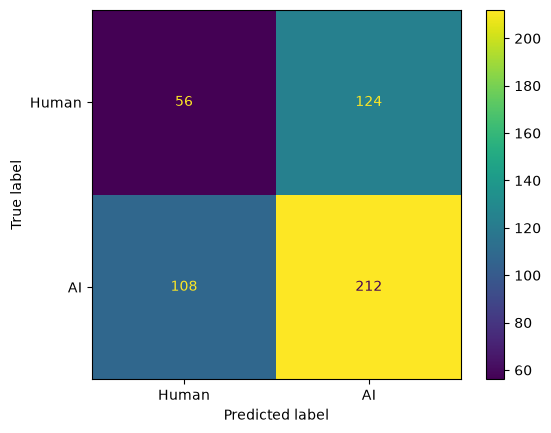

In [13]:
cm = metrics.confusion_matrix(data_module.train_ds.y, y_pred)
disp = metrics.ConfusionMatrixDisplay(cm,display_labels = ['Human', 'AI'])
disp.plot()
plt.savefig("../reports/figures/ConfusionMatrix.png", dpi=150)
plt.show()

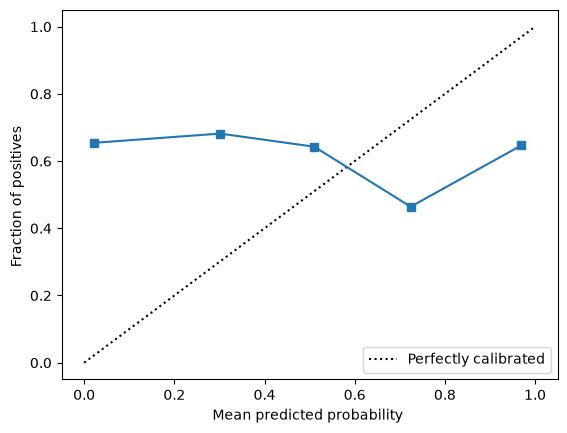

In [14]:
prob_true, prob_pred = calibration.calibration_curve(data_module.train_ds.y, y_prob[:,1])
disp = calibration.CalibrationDisplay(prob_true, prob_pred, y_prob)
disp.plot()
plt.savefig("../reports/figures/CalibrationCurve.png", dpi=150)
plt.show()

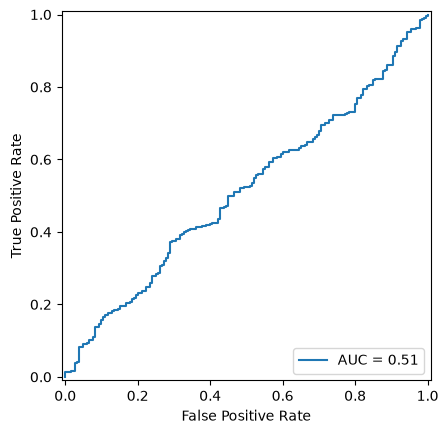

In [15]:
fpr, tpr, _ = metrics.roc_curve(data_module.train_ds.y,y_prob[:,1])
disp = metrics.RocCurveDisplay(fpr=fpr,tpr=tpr,roc_auc=metrics.auc(fpr,tpr))
disp.plot()
plt.savefig("../reports/figures/ROCCurve.png", dpi=150)
plt.show()

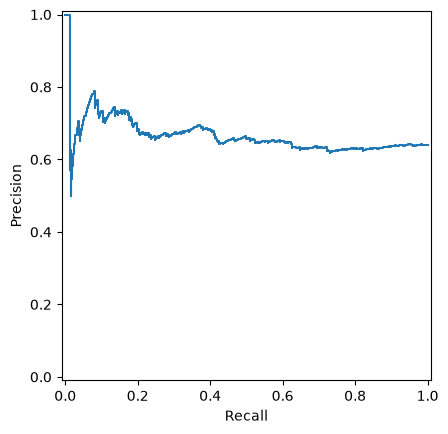

In [16]:
precision, recall, _ = metrics.precision_recall_curve(data_module.train_ds.y,y_prob[:,1])
disp = metrics.PrecisionRecallDisplay(precision,recall)
disp.plot()
plt.savefig("../reports/figures/PrecisionRecall.png", dpi=150)
plt.show()

C:\Users\Mikelats\AppData\Local\Temp\ipykernel_9544\2657792382.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
C:\Users\Mikelats\AppData\Local\Temp\ipykernel_9544\2657792382.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


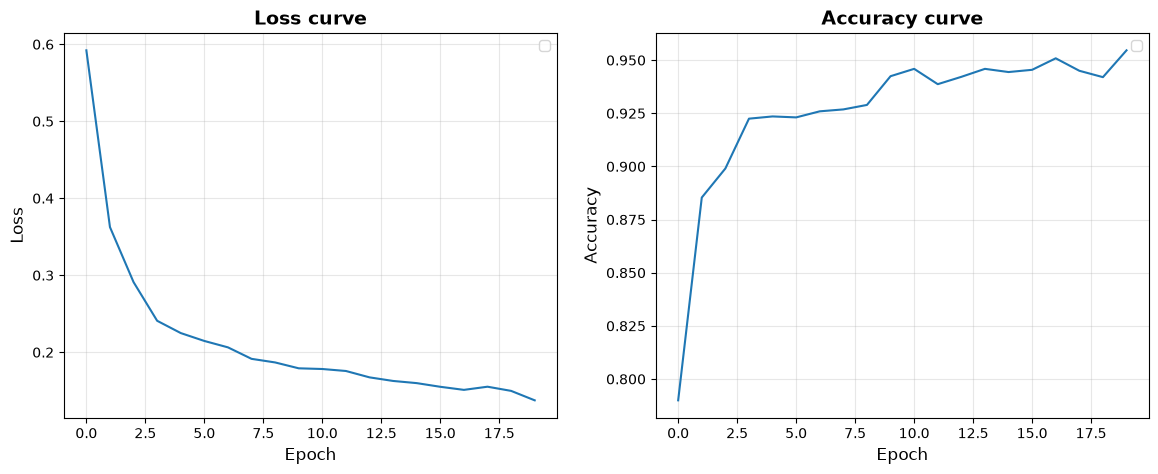

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(np.arange(len(net.train_losses)),net.train_losses)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Loss curve', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(np.arange(len(net.train_accs)),net.train_accs)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Accuracy curve', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.savefig("../reports/figures/LossAccuracyCurves.png", dpi=150)
plt.show()